# Policy gradients (REINFORCE) — a runnable, measured, *proven* build

Value methods (like **Q-learning**) learn how good each *action* is, then act greedily — which needs a small discrete action set to argmax over, and gives a deterministic policy. **Policy gradients** throw that detour out: parameterize the policy $\pi_\theta(a\mid s)$ directly with a neural network, run an episode, and push $\theta$ so the actions that led to reward become more likely. **REINFORCE** (Williams, 1992) is the simplest instance.

This notebook builds REINFORCE **from scratch** on **real** Gymnasium `CartPole-v1` and *proves* the two claims that matter:

- **The score-function estimator is correct.** On a tractable bandit we check with a hard `assert` that the REINFORCE gradient equals BOTH the exact analytic gradient AND a finite-difference of the objective — the policy-gradient theorem, verified end to end.
- **A baseline cuts variance without bias.** We confirm $\mathbb{E}[b\,\nabla\log\pi]=0$ numerically and *measure* that subtracting the mean return shrinks the gradient variance by ~an order of magnitude.

It imports the **exact same functions** as the companion page and its figures (from `reinforce.py`), so the numbers here are the numbers there. Everything is **seeded and CPU-pinned** for a reproducible trace.

> Companion page: **Policy Gradients (REINFORCE)**. Run top-to-bottom (Kernel → Restart & Run All). If Gymnasium is not installed, the module falls back to a real from-scratch corridor MDP — every run still executes on real data. Reinforcement learning is genuinely seed-sensitive; we say so honestly.

## Step 0 — Setup: import the real module and print versions

We import the pipeline from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions and the device. Training pins **CPU** for a reproducible trace (a tiny MLP on CartPole is faster on CPU than GPU transfer overhead anyway).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import reinforce as R

try:
    import gymnasium as gym
    gym_ver = gym.__version__
except ImportError:
    gym_ver = 'not installed (from-scratch fallback)'
print(f'torch {torch.__version__} | numpy {np.__version__} | gymnasium {gym_ver}')
print(f'best available device = {R.get_device()}  (training pinned to CPU for reproducibility, seed={R.SEED})')

torch 2.12.0 | numpy 2.4.6 | gymnasium 1.3.0
best available device = mps  (training pinned to CPU for reproducibility, seed=0)


## Step 1 — The environment: real CartPole, a continuous-state control task

**CartPole-v1**: a pole is hinged on a cart; the agent pushes the cart **left (0)** or **right (1)** each step to keep the pole upright. The observation is a 4-vector (cart position, cart velocity, **pole angle**, pole angular velocity) — *continuous*, which is already awkward for a value-table method. Reward is +1 for every step the pole stays up; the episode ends when the pole falls past ±12° or after 500 steps. The environment is **solved** at a mean return ≥ 475 over 100 episodes.

In [2]:
spec = R.make_env()
print(f'environment : {spec.label}   [{spec.source}]')
print(f'observation : {spec.n_obs}-dim continuous   actions: {spec.n_actions} (0=push left, 1=push right)')
print(f'solved bar  : mean return >= {spec.reward_threshold:.0f}   (episode cap = {spec.max_return:.0f})')

environment : CartPole-v1   [gymnasium]
observation : 4-dim continuous   actions: 2 (0=push left, 1=push right)
solved bar  : mean return >= 475   (episode cap = 500)


## Step 2 — The policy network: $\pi_\theta(a\mid s) = \mathrm{softmax}(\mathrm{MLP}(s))$

The whole difference from a value method is here: instead of a table of $Q(s,a)$, we have a small MLP that reads the state and outputs one **logit per action**; a softmax turns those into action *probabilities*. The policy is **stochastic** — we act by *sampling* from it, so it explores by its own randomness (no ε-greedy needed) — and **differentiable** in $\theta$, so $\log\pi_\theta$ has a gradient we can follow.

In [3]:
policy = R.PolicyNetwork(spec.n_obs, spec.n_actions)
obs, _ = spec.env.reset(seed=0)
dist = policy.distribution(torch.as_tensor(obs, dtype=torch.float32))
print('state           :', np.round(obs, 3))
print('action probs π  :', dist.probs.detach().numpy().round(3), ' (untrained -> near 50/50)')
a = dist.sample()
print(f'sampled action  : {int(a)}   log π(a|s) = {dist.log_prob(a).item():.3f}  (differentiable in θ)')

state           : [ 0.014 -0.023 -0.046 -0.048]
action probs π  : [0.482 0.518]  (untrained -> near 50/50)
sampled action  : 0   log π(a|s) = -0.730  (differentiable in θ)


## Step 3 — One rollout: run an episode under the current policy

To collect experience we roll out a full episode: at each state sample $a\sim\pi_\theta(\cdot\mid s)$, store $\log\pi_\theta(a\mid s)$ (with its gradient attached), step the environment, and record the reward. An *untrained* policy balances the pole for only a handful of steps — there is everything to learn.

In [4]:
roll = R.collect_rollout(policy, spec.env, seed=0)
print(f'episode length  : {len(roll.rewards)} steps   (untrained policy topples fast)')
print(f'total return    : {roll.total_reward:.0f}  (= steps balanced, since reward is +1 per step)')
print(f'stored log-probs: {roll.log_probs.shape[0]}  (one per action, each differentiable in θ)')

episode length  : 33 steps   (untrained policy topples fast)
total return    : 33  (= steps balanced, since reward is +1 per step)
stored log-probs: 33  (one per action, each differentiable in θ)


## Step 4 — Reward-to-go: credit each action with the future it could affect

For each step we need the return that *followed* it: the discounted **reward-to-go** $G_t = \sum_{k\ge t}\gamma^{k-t} r_{k+1}$. We use reward-to-go (not the whole-episode return on every step) because of **causality** — an action can't affect rewards collected *before* it, so including them only adds variance. Note $G_t$ is largest at the start (more future ahead) and decays to the last reward at the end.

In [5]:
G = R.reward_to_go(roll.rewards, gamma=0.99)
print(f'G_0 (start) = {G[0]:.2f}   G_mid = {G[len(G)//2]:.2f}   G_last = {G[-1]:.2f}')
print('reward-to-go decreases along the episode (less future remains):')
print(np.round(G.numpy()[:8], 2), '...')

G_0 (start) = 28.23   G_mid = 15.71   G_last = 1.00
reward-to-go decreases along the episode (less future remains):
[28.23 27.5  26.77 26.03 25.28 24.53 23.77 23.  ] ...


## Step 5 — The heart of it: the surrogate loss, and `backward()` IS the policy gradient

We don't assemble the gradient by hand. We write the scalar **surrogate loss**

$$L(\theta) = -\frac{1}{T}\sum_t \log\pi_\theta(a_t\mid s_t)\,A_t$$

and let autograd differentiate it. The minus sign turns gradient *descent* into *ascent* on expected return. Calling `loss.backward()` runs ordinary **backpropagation** through $\log\pi_\theta$ — the policy gradient is just backprop with the advantage $A_t$ as a per-step weight. Note $A_t$ is a **constant** (we differentiate through the log-prob, not the returns).

In [6]:
weights = R.advantages(G, baseline='mean')     # A_t = G_t - mean(G)  (a constant, not differentiated)
loss = R.reinforce_loss(roll.log_probs, weights)
policy.zero_grad()
loss.backward()                                # <- this is the policy gradient, computed by backprop
grad_norm = torch.cat([p.grad.flatten() for p in policy.parameters()]).norm().item()
print(f'surrogate loss  = {loss.item():.4f}')
print(f'gradient exists : ||∇θ L|| = {grad_norm:.4f}  (one backward() gave us the full policy gradient)')

surrogate loss  = 0.0570
gradient exists : ||∇θ L|| = 1.2635  (one backward() gave us the full policy gradient)


## Step 6 — The proof: the REINFORCE gradient equals the *exact* gradient

Is the score-function estimator actually right? On a small **3-armed bandit** the objective $J(\theta)=\mathbb{E}_{a\sim\pi}[R(a)]=\sum_a\pi(a)R(a)$ has a closed form, so we can get its gradient three independent ways: (a) **analytically** (autograd of the exact $J$), (b) by the **REINFORCE** estimate $\frac1N\sum_i R(a_i)\nabla\log\pi(a_i)$, and (c) by a **finite-difference** of $J$. If the log-derivative trick is correct, all three must agree. We `assert` it.

In [7]:
sp = R.prove_score_function(n_samples=200_000)
print('analytic ∇J     :', np.round(sp.analytic, 4))
print('REINFORCE MC    :', np.round(sp.reinforce_mc, 4))
print('finite-diff     :', np.round(sp.finite_diff, 4))
print(f'max|MC - analytic|         = {sp.mc_error:.2e}')
print(f'max|finite-diff - analytic|= {sp.fd_error:.2e}')
assert sp.mc_error < 5e-3 and sp.fd_error < 5e-3
print('OK: ∇θ E[R] = E[R ∇θ log π] verified — the policy-gradient theorem holds end to end.')

analytic ∇J     : [-0.0329  0.2383 -0.2054]
REINFORCE MC    : [-0.0329  0.2389 -0.2059]
finite-diff     : [-0.0329  0.2383 -0.2054]
max|MC - analytic|         = 5.86e-04
max|finite-diff - analytic|= 1.26e-10
OK: ∇θ E[R] = E[R ∇θ log π] verified — the policy-gradient theorem holds end to end.


## Step 7 — Why a baseline is free: it adds *zero* bias

A baseline $b(s)$ (a number that depends on the state but not the action) can be subtracted from the return without changing the gradient's expectation, because

$$\mathbb{E}_a[\nabla_\theta\log\pi(a\mid s)\,b(s)] = b(s)\sum_a\nabla_\theta\pi(a\mid s) = b(s)\,\nabla_\theta 1 = 0.$$

Let's confirm that expectation is ~0 numerically (up to Monte-Carlo noise).

In [8]:
err = R.prove_baseline_unbiased(baseline_b=5.0, n_samples=200_000)
print(f'max|E[b · ∇log π]| = {err:.2e}  (≈ 0 -> subtracting a state-only baseline adds no bias)')
assert err < 5e-2
print('OK: any state-only baseline is unbiased — we are free to choose it to cut variance.')

max|E[b · ∇log π]| = 2.73e-03  (≈ 0 -> subtracting a state-only baseline adds no bias)
OK: any state-only baseline is unbiased — we are free to choose it to cut variance.


## Step 8 — Train from scratch on real CartPole (with a baseline)

Now the full loop: for each episode, roll out → reward-to-go → subtract the mean baseline → one Adam step on the surrogate loss → discard the episode (REINFORCE is **on-policy**, so we can't reuse it). We train the headline seed with the mean baseline and watch the return climb toward the solved threshold. (This is a real training run — it takes ~30 s on CPU.)

trained 1000 episodes  |  final-100 mean return = 500.0  |  first solved at episode 266


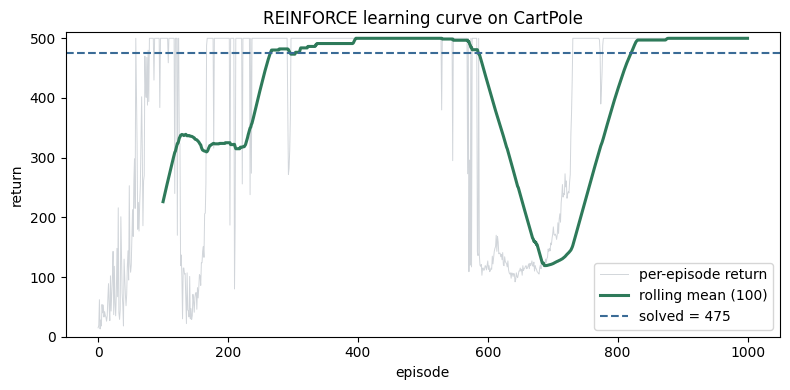

In [9]:
res = R.train_reinforce(R.make_env(), baseline='mean', n_episodes=R.CARTPOLE_EPISODES, seed=0)
solved = f'first solved at episode {res.solved_episode}' if res.solved_episode else 'not solved in budget'
print(f'trained {len(res.episode_returns)} episodes  |  final-100 mean return = {res.final_mean:.1f}  |  {solved}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res.episode_returns, color='#4A5B6E', alpha=0.25, lw=0.7, label='per-episode return')
w = len(res.episode_returns) - len(res.rolling_mean) + 1
ax.plot(np.arange(len(res.rolling_mean)) + w, res.rolling_mean, color='#2E7A5A', lw=2.2, label='rolling mean (100)')
ax.axhline(spec.reward_threshold, ls='--', color='#3A6B96', label=f'solved = {spec.reward_threshold:.0f}')
ax.set_xlabel('episode')
ax.set_ylabel('return')
ax.set_ylim(0, 510)
ax.set_title('REINFORCE learning curve on CartPole')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 9 — See it: the learned policy keeps the pole vertical

What did the policy actually learn? Roll out the trained policy and an untrained one, and plot the **pole angle** over time. The trained policy holds the angle in a tight band for the whole episode; the untrained one lets it fall past the ±12° limit within a few steps.

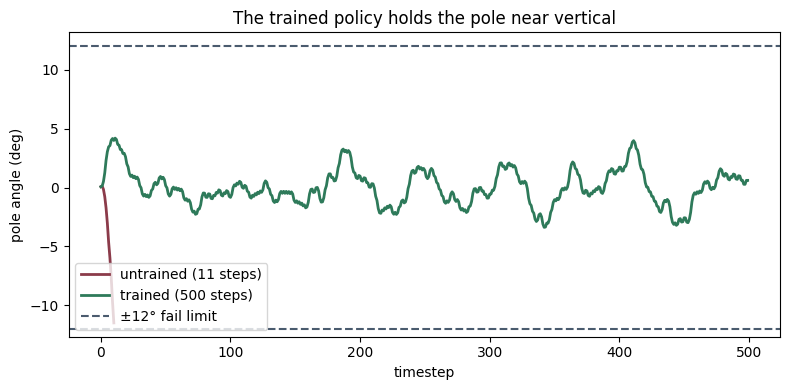

In [10]:
trained_roll = R.collect_rollout(res.policy, R.make_env().env, seed=99)
untrained_roll = R.collect_rollout(R.PolicyNetwork(spec.n_obs, spec.n_actions), R.make_env().env, seed=99)
deg = 180 / np.pi
plt.figure(figsize=(8, 4))
plt.plot(np.array(untrained_roll.pole_angles) * deg, color='#8B3B4A', lw=2,
         label=f'untrained ({len(untrained_roll.pole_angles)} steps)')
plt.plot(np.array(trained_roll.pole_angles) * deg, color='#2E7A5A', lw=2,
         label=f'trained ({len(trained_roll.pole_angles)} steps)')
plt.axhline(12, ls='--', color='#4A5B6E')
plt.axhline(-12, ls='--', color='#4A5B6E', label='±12° fail limit')
plt.xlabel('timestep')
plt.ylabel('pole angle (deg)')
plt.title('The trained policy holds the pole near vertical')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## Step 10 — Measure it: the baseline cuts gradient variance by ~an order of magnitude

The baseline is unbiased (Step 7) — but does it actually help? Freeze a partially-trained policy and compute the single-episode gradient many times, **with** and **without** the mean baseline, then compare the variance. Same expected direction, far less noise: that is why the baselined agent learns faster.

mean per-parameter gradient variance:
  no baseline   (A_t = G_t)          = 0.0848
  mean baseline (A_t = G_t - mean(G)) = 0.0120
  => variance reduced 7.1x by subtracting the baseline


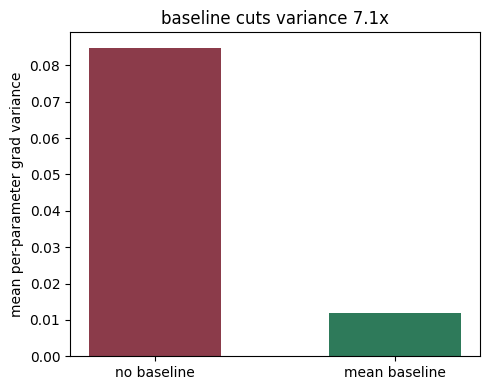

In [11]:
warm = R.train_reinforce(R.make_env(), baseline='mean', n_episodes=120, seed=0)
gv = R.measure_gradient_variance(R.make_env(), warm.policy, n_rollouts=200)
print('mean per-parameter gradient variance:')
print(f'  no baseline   (A_t = G_t)          = {gv.var_no_baseline:.4f}')
print(f'  mean baseline (A_t = G_t - mean(G)) = {gv.var_with_baseline:.4f}')
print(f'  => variance reduced {gv.reduction_factor:.1f}x by subtracting the baseline')
assert gv.reduction_factor > 2.0
plt.figure(figsize=(5, 4))
plt.bar(['no baseline', 'mean baseline'], [gv.var_no_baseline, gv.var_with_baseline],
        color=['#8B3B4A', '#2E7A5A'], width=0.55)
plt.ylabel('mean per-parameter grad variance')
plt.title(f'baseline cuts variance {gv.reduction_factor:.1f}x')
plt.tight_layout()
plt.show()

## Step 11 — With vs without a baseline: the learning curves

The variance reduction shows up directly in learning. Train the policy **with** and **without** a baseline across a couple of seeds and compare the mean learning curves: the baselined agent climbs faster and more steadily; plain REINFORCE ($A_t=G_t$) is noisier and slower. (Two seeds here for speed; the page uses more.)

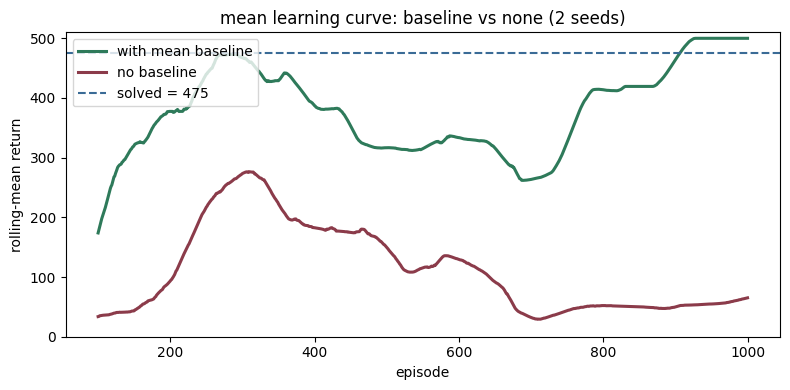

final-100 mean  with baseline: 500.0   no baseline: 65.1


In [12]:
seeds = [0, 1]
with_bl = [R.train_reinforce(R.make_env(), baseline='mean', n_episodes=R.CARTPOLE_EPISODES, seed=s) for s in seeds]
no_bl   = [R.train_reinforce(R.make_env(), baseline='none', n_episodes=R.CARTPOLE_EPISODES, seed=s) for s in seeds]
def mean_curve(runs):
    m = min(len(r.rolling_mean) for r in runs)
    return np.stack([r.rolling_mean[:m] for r in runs]).mean(0)
cw, cn = mean_curve(with_bl), mean_curve(no_bl)
w = R.CARTPOLE_EPISODES - len(cw) + 1
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(cw)) + w, cw, color='#2E7A5A', lw=2.2, label='with mean baseline')
plt.plot(np.arange(len(cn)) + w, cn, color='#8B3B4A', lw=2.2, label='no baseline')
plt.axhline(spec.reward_threshold, ls='--', color='#3A6B96', label='solved = 475')
plt.xlabel('episode')
plt.ylabel('rolling-mean return')
plt.ylim(0, 510)
plt.title('mean learning curve: baseline vs none (2 seeds)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
print(f'final-100 mean  with baseline: {np.mean([r.final_mean for r in with_bl]):.1f}   '
      f'no baseline: {np.mean([r.final_mean for r in no_bl]):.1f}')

## Step 12 — Honest interlude: RL is seed-sensitive

Reinforcement learning is famously high-variance *across random seeds*, and REINFORCE especially so — the same code and hyperparameters can solve on one seed and stall on another. This is not a bug to hide; it is a property of the method (single-episode Monte-Carlo gradients), and it is exactly why variance reduction (baselines → actor-critic → PPO) is the through-line of the whole policy-gradient story.

> (2 seeds here for a fast notebook run; the page's 3-seed spread is 498.5 ± 2.1 — policy-gradient variance means the exact numbers wobble across seeds.)

In [13]:
for s, r in zip(seeds, with_bl):
    tag = f'solved@{r.solved_episode}' if r.solved_episode else 'not solved in budget'
    print(f'seed {s}: final-100 mean = {r.final_mean:6.1f}   ({tag})')
finals = [r.final_mean for r in with_bl]
print(f'spread across seeds: mean {np.mean(finals):.1f} +/- {np.std(finals):.1f}')
print('=> report the spread, never a single lucky seed. Variance reduction is the whole game.')

seed 0: final-100 mean =  500.0   (solved@266)
seed 1: final-100 mean =  500.0   (solved@914)
spread across seeds: mean 500.0 +/- 0.0
=> report the spread, never a single lucky seed. Variance reduction is the whole game.


## Step 13 — Try it: predict, then check

Before running, *predict the direction*. **(1)** With the baseline **off**, how much noisier is the single-episode gradient — and does training slow? **(2)** If you raise the learning rate 5×, does it learn faster or **collapse** (return climbs then crashes as the policy commits prematurely)? Write your guess, change the one line below, and check. Being *wrong* about the direction is where the learning is.

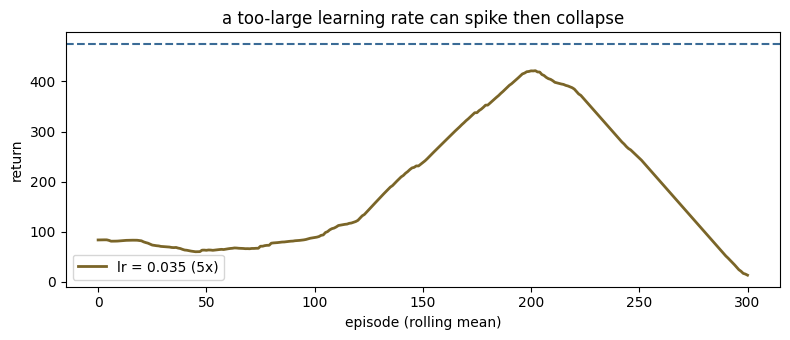

final-100 mean at 5x lr = 13.4  (compare to the stable run in Step 8)


In [14]:
# (1) gradient variance without the baseline is already measured in Step 10 (the 'no baseline' bar).
# (2) crank the learning rate and watch for collapse (return rising then crashing):
hot = R.train_reinforce(R.make_env(), baseline='mean', n_episodes=400, lr=5 * R.CARTPOLE_LR, seed=0)
plt.figure(figsize=(8, 3.5))
plt.plot(hot.rolling_mean, color='#7A6528', lw=2, label=f'lr = {5*R.CARTPOLE_LR:.3f} (5x)')
plt.axhline(spec.reward_threshold, ls='--', color='#3A6B96')
plt.xlabel('episode (rolling mean)')
plt.ylabel('return')
plt.title('a too-large learning rate can spike then collapse')
plt.legend()
plt.tight_layout()
plt.show()
print(f'final-100 mean at 5x lr = {hot.final_mean:.1f}  (compare to the stable run in Step 8)')

## Recap

You built REINFORCE from scratch and **proved** it: the score-function gradient matches the exact analytic gradient and a finite difference (the policy-gradient theorem, end to end), a state-only baseline is unbiased and cuts gradient variance by ~an order of magnitude, and a policy network trained by $L=-\frac1T\sum_t\log\pi_\theta(a_t\mid s_t)\,A_t$ climbs to CartPole's solved threshold — with honest seed variance. The engine is one line of autograd; `loss.backward()` *is* the policy gradient.

See the companion page for the full derivation (the log-derivative trick, why the dynamics vanish, the baseline unbiasedness proof), the pitfalls (high variance, premature collapse, on-policy sample inefficiency), and where it goes next: make the baseline a **learned value function** and you have **actor-critic**; add a clipped surrogate and data reuse and you have **PPO** — the algorithm behind RLHF.